# Entangling Quantum Gates for Coupled Transmon Qubits

$
\gdef\bra#1{\langle#1\vert}
\gdef\ket#1{\vert#1\rangle}
\gdef\braket#1{\langle#1\rangle}
$

In this notebook, we'll use the `QuantumControl` framework for an optimization towards a perfectly entangling
two-qubit gate for a system of two transmon qubits with a shared transmission
line.

In [1]:
using QuantumControl

It goes through three progressively more advanced optimizations:

1. The direct optimization for a $\hat{O} = \sqrt{\text{iSWAP}}$ gate with a
   standard square-modulus functional
2. The direct maximization of the gate concurrence with semi-automatic differentiation
3. The optimization towards a perfect entangler using the functional demonstrated in [Watts *et al.*, Phys. Rev. A 91, 062306 (2015)](https://michaelgoerz.net/#WattsPRA2015) and [Goerz *et al.*, Phys. Rev. A 91, 062307 (2015)](https://michaelgoerz.net/#GoerzPRA2015)

While the first example evaluates the gradient of the optimization functional
analytically, the latter two are examples for the use of automatic
differentiation, or more specifically semi-automatic differentiation, as
developed in [Goerz *et al.*, Quantum 6, 871 (2022)](https://quantum-journal.org/papers/q-2022-12-07-871/). The optimization of the gate
concurrence specifically illustrates the optimization of a functional that is
inherently non-analytical.

Unlike a simple state-to-state transfer, where the optimization considers the time evolution of only a single quantum state, the optimization of a quantum gate takes into account the evolution of multiple quantum states (the logical two-qubit basis states $\ket{00}$, $\ket{01}$, $\ket{10}$, $\ket{11}$). We will see how to work with such more general functionals, and how the functional and the dynamic states enter the optimization in Krotov's method and GRAPE.

The model is realistic in that the logical subspace is embedded in a larger Hilbert space, and the tutorial illustrates the use of semi-automatic differentiation with both Krotov's method and GRAPE.

## Setup

Krotov's Method and GRAPE can be used interchangeably in these optimizations:

In [2]:
using Krotov
using GRAPE

Simulating the dynamics will be done via the `QuantumPropagators` package. Both the Krotov and GRAPE method work on control fields that are piecewise-constant (defined as constant in each interval of the time grid). That is, for each time step, the time evolution operator is simply $\exp(-i \hat{H}_n dt)$ with a constant $\hat{H}_n$ for the time step $dt$. For trivially small systems, one can evaluate the time evolution operator with direct matrix exponentiation (`QuantumPropagators.ExpProp`, as we have used in previous examples). For slightly larger systems, a very efficient method for simulating the time evolution in each time step is to expand the matrix exponential into Chebychev polynomials. This is implemented as the `Cheby` propagation method:

In [3]:
using QuantumPropagators: Cheby

For visualization, we will use the `Plots` package

In [4]:
using Plots

# Set up thicker default lines in plots
Plots.default(
    linewidth               = 2.0,
    foreground_color_legend = nothing,
    background_color_legend = RGBA(1, 1, 1, 0.8)
)

In [5]:
# Utility for displaying the source code of a function (@show_code macro)
include(joinpath("utils", "show_code.jl"));

## Model

<img src="figures/transmon.png" alt="Transmon System" style="width: 1200px;"/>

We consider here a system of two [transmon](https://en.wikipedia.org/wiki/Transmon) qubits, the green in the above schematic, with a shared transmission line ("cavity"), blue, as described in [Blais *et al.*, Phys. Rev. A 75, 032329 (2007)](https://arxiv.org/abs/cond-mat/0612038). Each qubit is an anharmonic "Duffing" oscillator

$$
\hat{H}_q = \left(\omega_q - \frac{\alpha_q}{2}\right) \hat{n} + \frac{\alpha_q}{2} \hat{n}^2
$$

where $\omega_q$ is the separation of the two lowest "qubit" levels $\ket{0}$ and $\ket{1}$, $\alpha_q$ is the qubit anharmonicity, and $\hat{n}$ is the number operator. The two qubits can exchange excitations with the cavity. In the "dispersive limit" where the coupling $g$ between each qubit and the cavity is weak, the cavity only has "virtual excitations" and can be eliminated for a simpler "effective" model containing only transmon levels. In this effective model, the two qubits have an always-on coupling $J$ (they exchange excitations via the cavity at a certain rate), and the microwave driving field in the transmission line now drives the transitions between the transmon levels with an effective coupling $g^\text{eff}$. As a "qubit", the population should only be in the two lowest "logical" levels $\ket{0}$ and $\ket{1}$, but during a gate operation, population may go into higher levels of each transmon, depending on the strength of the driving field and the magnitude of the anharmonicity. This is fine, as long as the population returns to the logical subspace at the end of the gate operation (or else, at that point, population in higher levels would be considered "lost" and reduce the gate fidelity). Numerically, we can truncate the transmon to e.g. $N=6$ levels, if we can verify that the control field only populates levels $\ket{0}$ – $\ket{4}$ at any time.

We will write the Hamiltonian in units of GHz, where a qubit frequency "4.3 GHz" means that the qubit levels are separated by an energy of $E = h \cdot 4.3\text{GHz} = \hbar \cdot 2\pi \cdot 4.3\text{GHz}$. When solving the Schrödinger equation numerically, we always work with $\hbar = 1$, so GHz units with an implicit factor of $2\pi$ are natural. The natural units of time to make the Hamiltonian dimensionless are then ns ($E \cdot dt$ should be a phase).

In [6]:
const GHz = 2π
const MHz = 0.001GHz
const ns = 1.0
const μs = 1000ns;

The Hamiltonian and parameters are taken from
Ref. [Goerz *et al.*, Phys. Rev. A 91, 062307
   (2015), Table 1](https://michaelgoerz.net/#GoerzPRA2015), and we can write out the effective two-transmon Hamiltonian as

In [7]:
⊗ = kron
const 𝕚 = 1im
const N = 6  # levels per transmon

using LinearAlgebra
using SparseArrays


function transmon_hamiltonian(;
    Ωre,
    Ωim,
    N=N,  # levels per transmon
    ω₁=4.380GHz,
    ω₂=4.614GHz,
    ωd=4.498GHz, # frequency of rotating frame
    α₁=-210MHz,
    α₂=-215MHz,
    J=-3MHz,
    λ=1.03,
    use_sparse=:auto
)
    𝟙 = SparseMatrixCSC{ComplexF64,Int64}(sparse(I, N, N))
    b̂₁ = spdiagm(1 => complex.(sqrt.(collect(1:N-1)))) ⊗ 𝟙
    b̂₂ = 𝟙 ⊗ spdiagm(1 => complex.(sqrt.(collect(1:N-1))))
    b̂₁⁺ = sparse(b̂₁')
    b̂₂⁺ = sparse(b̂₂')
    n̂₁ = sparse(b̂₁' * b̂₁)
    n̂₂ = sparse(b̂₂' * b̂₂)
    n̂₁² = sparse(n̂₁ * n̂₁)
    n̂₂² = sparse(n̂₂ * n̂₂)
    b̂₁⁺_b̂₂ = sparse(b̂₁' * b̂₂)
    b̂₁_b̂₂⁺ = sparse(b̂₁ * b̂₂')

    ω̃₁ = ω₁ - ωd  # rotating frame frequencies
    ω̃₂ = ω₂ - ωd

    Ĥ₀ = sparse(
        (ω̃₁ - α₁ / 2) * n̂₁ +
        (α₁ / 2) * n̂₁² +
        (ω̃₂ - α₂ / 2) * n̂₂ +
        (α₂ / 2) * n̂₂² +
        J * (b̂₁⁺_b̂₂ + b̂₁_b̂₂⁺)
    )

    Ĥ₁re = (1 / 2) * (b̂₁ + b̂₁⁺ + λ * b̂₂ + λ * b̂₂⁺)
    Ĥ₁im = (𝕚 / 2) * (b̂₁⁺ - b̂₁ + λ * b̂₂⁺ - λ * b̂₂)

    if ((N < 5) && (use_sparse ≢ true)) || use_sparse ≡ false
        # For small Hilbert spaces, it is more efficient to work with
        # dense matrices
        H = hamiltonian(Array(Ĥ₀), (Array(Ĥ₁re), Ωre), (Array(Ĥ₁im), Ωim))
    else
        H = hamiltonian(Ĥ₀, (Ĥ₁re, Ωre), (Ĥ₁im, Ωim))
    end
    return H

end;

The Hamiltonian is written in a rotating frame, so in general, the control
field is allowed to be complex-valued. We have separated this into two control
fields, one for the real part and one for the imaginary part. Initially, the
imaginary part is zero, corresponding to a field exactly at the frequency of
the rotating frame.

We choose a pulse duration of 400 ns. The guess pulse amplitude is 35 MHz,
with a 15 ns switch-on/-off time. The amplitude already contains the $g^\text{eff}$ factor, i.e., how much amplitude of the physical field the transmon actually feels. The factor might be different for the two qubits, which we've taken into account here with a factor $\lambda$.

This switch-on/-off must be maintained in
the optimization: A pulse that does not start from or end at zero would not
be physical. For GRAPE, we can achieve this by using a `ShapedAmplitude`:

In [8]:
using QuantumControl.Amplitudes: ShapedAmplitude

This allows to have a control amplitude $Ω(t) = S(t) ϵ(t)$ where $S(t)$
is a fixed shape and $ϵ(t)$ is the pulse directly tuned by the
optimization. We start with a constant $ϵ(t)$ and do not place any
restrictions on how the optimization might update $ϵ(t)$. Krotov's method has an alternative way to ensure this boundary condition by containing an "update shape" that limits the pulse update in each iteration to be zero at the boundary points, but the `ShapedAmplitude` makes this unnecessary and works equally well for GRAPE and Krotov's method.

We define both the control $ϵ(t)$ and the shape $S(t)$ as functions of time. A
`ShapedAmplitude` also accepts pre-discretized vectors, but keeping the shape as
a function lets us substitute the optimized control (which the optimizer returns
discretized on the time grid) back into the amplitude later without any
discretization mismatch.

In [9]:
using QuantumControl.Shapes: flattop

function guess_amplitudes(; T=400ns, E₀=35MHz, dt=0.1ns, t_rise=15ns)

    tlist = collect(range(0, T, step=dt))
    shape(t) = flattop(t, T=T, t_rise=t_rise)
    Ωre = ShapedAmplitude(t -> E₀; shape)
    Ωim = ShapedAmplitude(t -> 0.0; shape)

    return tlist, Ωre, Ωim

end

tlist, Ωre_guess, Ωim_guess = guess_amplitudes();

We can visualize this:

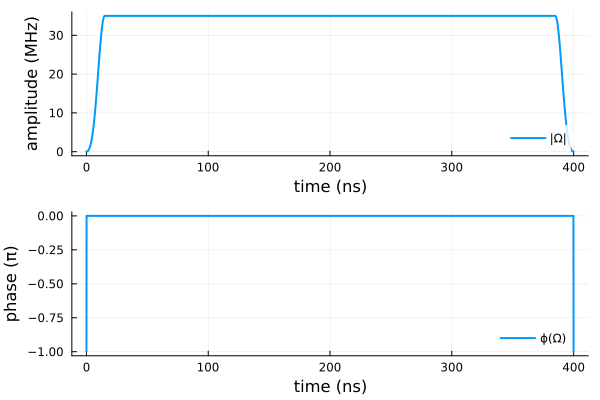

In [10]:
using QuantumControl.Controls: discretize

function plot_complex_pulse(tlist, Ω; time_unit=:ns, ampl_unit=:MHz, kwargs...)

    # make sure Ω is defined on the *points* of `tlist`
    Ω = discretize(real.(Ω), tlist) .+ 𝕚 .* discretize(imag.(Ω), tlist)

    ax1 = plot(
        tlist ./ eval(time_unit),
        abs.(Ω) ./ eval(ampl_unit);
        label="|Ω|",
        xlabel="time ($time_unit)",
        ylabel="amplitude ($ampl_unit)",
        kwargs...
    )

    ax2 = plot(
        tlist ./ eval(time_unit),
        angle.(Ω) ./ π;
        label="ϕ(Ω)",
        xlabel="time ($time_unit)",
        ylabel="phase (π)"
    )

    plot(ax1, ax2, layout=(2, 1))

end

fig = plot_complex_pulse(tlist, [Ωre_guess(t) + 𝕚 * Ωim_guess(t) for t ∈ tlist])

We now instantiate the Hamiltonian with these control fields:

In [11]:
H = transmon_hamiltonian(Ωre=Ωre_guess, Ωim=Ωim_guess);

## Logical basis for two-qubit gates

For simplicity, we will define the qubits in the *bare* basis, i.e.
ignoring the static coupling $J$.

In [12]:
function ket(i::Int64; N=N)
    Ψ = zeros(ComplexF64, N)
    Ψ[i+1] = 1
    return Ψ
end

function ket(indices::Int64...; N=N)
    Ψ = ket(indices[1]; N=N)
    for i in indices[2:end]
        Ψ = Ψ ⊗ ket(i; N=N)
    end
    return Ψ
end

function ket(label::AbstractString; N=N)
    indices = [parse(Int64, digit) for digit in label]
    return ket(indices...; N=N)
end;

In [13]:
basis = [ket("00"), ket("01"), ket("10"), ket("11")];

It would be more realistic to work in the "dressed" basis of the eigenstates closest to the bare states. However, since $J$ is relatively small, the bare and dressed states are quite close to each other, and for the purpose of this example we avoid the complication of having to diagonalize the Hamiltonian and choosing the correct basis states.

## Optimizing for a specific quantum gate

Our target gate is $\hat{O} = \sqrt{\text{iSWAP}}$:

In [14]:
SQRTISWAP = [
    1  0    0   0
    0 1/√2 𝕚/√2 0
    0 𝕚/√2 1/√2 0
    0  0    0   1
];

We could optimize for any other gate like the standard CNOT and CPHASE gates as well, but based on the interaction terms in the Hamiltonian $\sqrt{\text{iSWAP}}$ is a very natural gate for this system.

For each basis state, we get a target state that results from applying the
gate to the basis state (you can convince yourself that this is equivalent to
multiplying the transpose of the above gate matrix to the vector of basis
states):

In [15]:
basis_tgt = transpose(SQRTISWAP) * basis;

The optimization aims to bring the dynamic trajectory of each basis
state to the corresponding target state:

In [16]:
trajectories = [
    Trajectory(initial_state=Ψ, target_state=Ψtgt, generator=H) for
    (Ψ, Ψtgt) ∈ zip(basis, basis_tgt)
];

We can analyze how all of the basis states evolve under the guess controls in
one go:

In [17]:
guess_states = propagate_trajectories(trajectories, tlist; method=Cheby, use_threads=true);

The gate implemented by the guess controls is

In [18]:
U_guess = [basis[i] ⋅ guess_states[j] for i = 1:4, j = 1:4];

We will optimize these trajectories with a square-modulus functional

$$
J_{T,sm}
= 1 - \Bigg\vert\frac{1}{4}\sum_{k=1}^{4} \underbrace{\langle \Psi_k(T) | \Psi_k^{\text{tgt}}\rangle}_{\equiv \tau_k}\Bigg\vert^2
= 1 - \frac{1}{16} \sum_{k,l=1}^{4} \underbrace{\langle \Psi_l^{\text{tgt}} | \Psi_l(T) \rangle}_{\equiv\tau_l^*} \; \underbrace{\langle \Psi_k(T) | \Psi_k^{\text{tgt}}\rangle}_{\equiv \tau_k}
$$

where $\ket{\Psi_k(T)}$ is the result of forward-propagating the basis state $\ket{\phi_k}$ (i.e., $\ket{\phi_1} = \ket{00}$, $\ket{\phi_2} = \ket{01}$, etc.)

In [19]:
using QuantumControl.Functionals: J_T_sm

The initial value of the functional is

In [20]:
J_T_sm(guess_states, trajectories)

0.9156372510989285

which is the gate error

In [21]:
1 - (abs(tr(U_guess' * SQRTISWAP)) / 4)^2

0.9156372510989285

Recall the fundamental scheme for how the control gradient is calculated in GRAPE, respectively, the pulse update in Krotov's method:

<img src="figures/schemes.svg" alt="Schemes" style="width: 1200px;"/>

The figure is from [Goerz *et al.*, Quantum 6, 871 (2022)](https://quantum-journal.org/papers/q-2022-12-07-871/), which discusses it in detail.

Here, we'll focus on one essential feature: both in GRAPE and Krotov, the scheme involves a forward-propagation of the four basis states ($\ket{\phi_k} \rightarrow \ket{\Psi_k(T)}$ in the diagram), followed by a backward propagation of a set of states $\ket{\chi_k}$ with the boundary condition

$$
\ket{\chi_k(T)} = - \frac{\partial J_T}{\partial \bra{\Psi_k(T)}}
$$

This is how (and only how) the functional enters the optimization!

### Boundary condition for the backward propagation

The `QuantumControl.optimize` function, respectively the `QuantumControl.ControlProblem`, takes a function `chi` as a keyword argument that constructs the states $\ket{\chi_k(T)}$ from the set of forward-propagated states $\ket{\Psi_k(T)}$ and the `trajectories` (which contain the `target_state` for each basis state).

For the $J_{T,sm}$ as defined above, the $\ket{\chi_k(T)}$ turn out to be proportional to the target states $\ket{\Psi_k^{\text{tgt}}}$. Treating $\ket{\Psi_k(T)}$ and $\bra{\Psi_k(T)}$ as independent (the "Wirtinger derivatives" that justify treating a complex variable and its conjugate as independent), only the factor $\tau_k = \braket{\Psi_k(T)|\Psi_k^{\text{tgt}}}$ depends on $\bra{\Psi_k(T)}$, with $\partial \tau_k / \partial \bra{\Psi_k(T)} = \ket{\Psi_k^{\text{tgt}}}$. Therefore,

$$
\ket{\chi_k(T)} = - \frac{\partial J_T}{\partial \bra{\Psi_k(T)}}
= \underbrace{\frac{1}{16} \sum_{l=1}^{4} \tau_l^*}_{\equiv\, \alpha} \, \ket{\Psi_k^{\text{tgt}}}
$$

The minus sign in the definition of $\ket{\chi_k}$ cancels the minus sign from $J_T = 1 - \dots$. In code, `sum(τ')` evaluates $\sum_l \tau_l^*$ (the adjoint `'` conjugates the elements):

In [22]:
"""Return the χ-states for the boundary condition of the backward propagation.

The function receives the forward-propagated states `Ψ` and the `trajectories`,
and returns the list of states `χ`. An optimizer may call it with keyword
arguments, which we ignore here.
"""
function chi(Ψ, trajectories; kwargs...)
    τ = [Ψ[k] ⋅ trajectories[k].target_state for k = 1:4]
    α = sum(τ') / 16
    return [α * trajectories[k].target_state for k = 1:4]
end

chi

Now, we define the full optimization problem on top of the list of
trajectories, and with the optimization functional and the definition of `chi`:

In [23]:
problem = ControlProblem(
    trajectories,
    tlist;
    iter_stop=100,
    J_T=J_T_sm,
    chi=chi,
    check_convergence=res -> begin
        (
            (res.J_T > res.J_T_prev) &&
            (res.converged = true) &&
            (res.message = "Loss of monotonic convergence")
        )
        ((res.J_T <= 1e-3) && (res.converged = true) && (res.message = "J_T < 10⁻³"))
    end,
    prop_method=Cheby,
    use_threads=true,
);

Solve the optimization problem with GRAPE:

In [24]:
opt_result = optimize(problem; method=GRAPE)

 iter.        J_T       ǁ∇Jǁ       ǁΔϵǁ         ΔJ   FG(F)    secs
     0   9.16e-01   1.41e-01        n/a        n/a    1(0)     2.0
     1   8.94e-01   1.41e-01   1.41e-01  -2.19e-02    1(0)     0.2
     2   8.85e-01   2.36e-01   2.36e-01  -8.30e-03    1(0)     0.1
     3   8.52e-01   6.54e-01   6.29e-02  -3.35e-02    1(0)     0.1
     4   7.97e-01   4.18e-01   3.38e-01  -5.47e-02    1(0)     0.2
     5   5.81e-01   9.12e-01   5.07e-01  -2.16e-01    2(0)     0.3
     6   4.49e-01   1.15e+00   2.28e-01  -1.32e-01    2(0)     0.3
     7   4.27e-01   6.34e-01   7.33e-02  -2.16e-02    2(0)     0.3
     8   3.97e-01   4.43e-01   8.66e-02  -3.06e-02    1(0)     0.1
     9   2.82e-01   4.53e-01   6.62e-01  -1.15e-01    1(0)     0.2
    10   1.96e-01   1.28e+00   1.54e-01  -8.51e-02    1(0)     0.2
    11   1.83e-01   6.70e-01   2.59e-01  -1.31e-02    1(0)     0.2
    12   1.61e-01   8.17e-01   7.79e-02  -2.23e-02    1(0)     0.1
    13   1.53e-01   3.98e-01   8.59e-02  -7.98e-03    1(0)    

GRAPE Optimization Result
-------------------------
- Started at 2026-06-25T10:49:16.108
- Number of trajectories: 4
- Number of iterations: 38
- Number of pure func evals: 0
- Number of func/grad evals: 43
- Value of functional: 9.20597e-04
- Reason for termination: J_T < 10⁻³
- Ended at 2026-06-25T10:49:24.104 (7 seconds, 996 milliseconds)


Alternatively to GRAPE, we can use Krotov's method to run the same optimization. Krotov's method has a parameter `lambda_a` that determines the overall magnitude of the pulse update (larger `lambda_a` result in smaller updates):

In [25]:
opt_result = optimize(problem; method=Krotov, lambda_a=10.0)

 iter.        J_T   ∫gₐ(t)dt          J       ΔJ_T         ΔJ    secs
     0   9.16e-01   0.00e+00   9.16e-01        n/a        n/a     0.5
     1   9.07e-01   3.49e-03   9.10e-01  -8.81e-03  -5.32e-03     0.7
     2   8.95e-01   4.80e-03   8.99e-01  -1.23e-02  -7.51e-03     0.4
     3   8.76e-01   7.54e-03   8.83e-01  -1.88e-02  -1.12e-02     0.3
     4   8.26e-01   2.11e-02   8.47e-01  -4.94e-02  -2.83e-02     0.3
     5   6.29e-01   7.93e-02   7.08e-01  -1.97e-01  -1.18e-01     0.4
     6   4.37e-01   8.62e-02   5.23e-01  -1.92e-01  -1.06e-01     0.3
     7   3.81e-01   2.73e-02   4.08e-01  -5.58e-02  -2.85e-02     0.3
     8   3.27e-01   2.65e-02   3.53e-01  -5.40e-02  -2.75e-02     0.3
     9   2.72e-01   2.68e-02   2.99e-01  -5.45e-02  -2.78e-02     0.3
    10   2.22e-01   2.49e-02   2.46e-01  -5.05e-02  -2.57e-02     0.3
    11   1.80e-01   2.07e-02   2.00e-01  -4.20e-02  -2.13e-02     0.3
    12   1.48e-01   1.57e-02   1.64e-01  -3.17e-02  -1.61e-02     0.3
    13   1.25e-01   

Krotov Optimization Result
--------------------------
- Started at 2026-06-25T10:49:24.800
- Number of trajectories: 4
- Number of iterations: 53
- Value of functional: 9.42594e-04
- Reason for termination: J_T < 10⁻³
- Ended at 2026-06-25T10:49:43.861 (19 seconds, 61 milliseconds)


We extract the optimized control field from the optimization result and plot
the resulting amplitude.

The `optimized_controls` field of the `opt_result` contains the optimized
controls $ϵ(t)$.

In [26]:
ϵ_opt = opt_result.optimized_controls[1] + 𝕚 * opt_result.optimized_controls[2];

These must still be multiplied by the static shape $S(t)$ that we set up
for the guess amplitudes

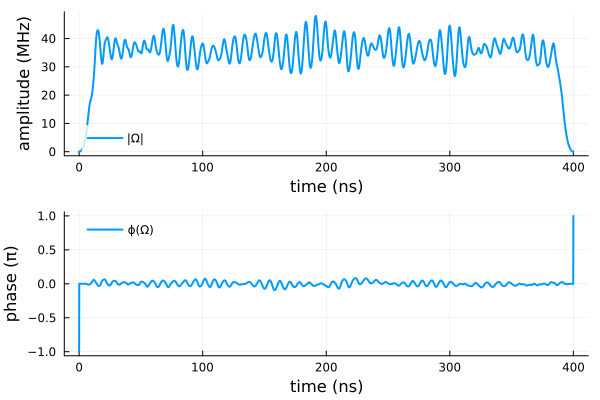

In [27]:
Ω_opt = ϵ_opt .* discretize(Ωre_guess.shape, tlist)

fig = plot_complex_pulse(tlist, Ω_opt)

Once we are happy with the optimization result, we propagate the optimized control field to analyze the resulting
quantum gate. We substitute the optimized controls for the original guess controls in the trajectories, and propagate:

In [28]:
using QuantumControl.Controls: get_controls, substitute

opt_states = propagate_trajectories(
    substitute(
        trajectories,
        IdDict(zip(get_controls(trajectories), opt_result.optimized_controls))
    ),
    tlist;
    method=Cheby,
    use_threads=true
);

The resulting gate is

In [29]:
U_opt = [basis[i] ⋅ opt_states[j] for i = 1:4, j = 1:4];

and we can verify the resulting fidelity

In [30]:
(abs(tr(U_opt' * SQRTISWAP)) / 4)^2

0.9990574058825553

## Maximization of the gate concurrence

Building a quantum computer requires a "universal gate" set. Traditionally, this set consists of a specific two-qubit gate (often CNOT), and all single-qubit gates (under the assumption that single-qubit gates are "easy" to realize). However the universal set does not need to contain CNOT (or some other gate) *specifically*. What matters for universal quantum computing is the ability to create entanglement.

Any two-qubit gate (any 4 × 4 unitary) has a "gate concurrence", which is the maximum entanglement (concurrence) of a state that can be obtained by applying the gate to some separable input state. A `gate_concurrence` function is implemented in the `TwoQubitWeylChamber` package – the Weyl chamber is a mathematical structure (illustrated below) that describes and classifies two-qubit gates in terms of entangling power and equivalence with respect to single-qubit operations.

<img src="figures/weylchamber.svg" alt="Weyl Chamber" style="width: 800px;"/>

The structure behind the diagram is the *Cartan decomposition*: any two-qubit gate (any $4 \times 4$ unitary) can be written, up to a global phase, as

$$
\hat{U} = \hat{k}_1
         \exp\!\left[\frac{i}{2}\left(
             c_1\, \hat{σ}_x \hat{σ}_x
           + c_2\, \hat{σ}_y \hat{σ}_y
           + c_3\, \hat{σ}_z \hat{σ}_z
         \right)\right]
         \hat{k}_2,
$$

where $\hat{k}_1$ and $\hat{k}_2$ are *local* (single-qubit) operations, $\hat{k}_i = \hat{U}_i^{(1)} \otimes \hat{U}_i^{(2)}$ with $\hat{U}_i^{(1,2)} \in SU(2)$, and the central factor is the genuinely *non-local* part, parametrized by three real coefficients $(c_1, c_2, c_3)$. All of the entangling power of $\hat{U}$ lives in that central factor; the local gates $\hat{k}_1, \hat{k}_2$ contribute none.

This means two gates that differ only by single-qubit operations share the same $(c_1, c_2, c_3)$. We call such gates *locally equivalent* and group them into a *local equivalence class*. For example, CNOT and CPHASE differ only by two Hadamards, so they are in the same class. Since we assume single-qubit gates are "easy", what matters for universal computing is only the equivalence class, i.e., the non-local content of the gate.

Each point $(c_1, c_2, c_3)$ thus represents one equivalence class. After removing the remaining symmetries in the coefficients, the set of inequivalent classes forms the geometric shape shown above, the *Weyl chamber*. The corners and edges correspond to familiar gates ($O$ = identity / all local gates, $L$ = [CNOT/CPHASE], $Q$ = $[\sqrt{\text{iSWAP}}]$, $A_3$ = [SWAP], etc.), and the shaded polyhedron in the interior is exactly the set of equivalence classes that are perfect entanglers.

In [31]:
using TwoQubitWeylChamber: gate_concurrence

Most of the "standard" two-qubit gates like $\sqrt{\text{iSWAP}}$ and CNOT (points Q and L, respectively, in the diagram) are "perfect entanglers":

In [32]:
gate_concurrence(SQRTISWAP)

1.0

In [33]:
CNOT = [
    1 0 0 0
    0 1 0 0
    0 0 0 1
    0 0 1 0
]

gate_concurrence(CNOT)

1.0

The gate concurrence of the identity or any other random $SU(2) \times SU(2)$ matrix (independent single-qubit gates) is zero:

In [34]:
gate_concurrence(I(4))

0.0

In [35]:
function random_unitary(N)
    H = rand(N, N)
    return exp(𝕚 * (H + H'))
end

U = random_unitary(2) ⊗ random_unitary(2)
round(gate_concurrence(U); digits=10)

0.0

And in general, the gate concurrence of a random $4 \times 4$ unitary is a number between 0 and 1, heavily skewing towards 1: the majority of $4 \times 4$ unitaries are perfect entanglers.

In [36]:
for _ = 1:10
    display(round(gate_concurrence(random_unitary(4)); digits=2))
end

1.0

1.0

0.93

0.62

0.58

0.95

0.92

1.0

1.0

1.0

This fact makes the gate concurrence an attractive optimization target: by optimizing the entangling power of the two-qubit gate without targeting a *specific* gate, we may identify the perfect entangler that is "easiest" to achieve with the given Hamiltonian.

We can also check that for the guess pulse, we are not implementing a perfect
entangler

In [37]:
gate_concurrence(U_guess)

0.7773116198507106

For the transmon system, we also have to take into account that population may be lost from the logical subspace: the `gate_concurrence` is only well-defined for a unitary $\hat{U}$, whereas a $\hat{U}$ obtained by projecting the four propagated basis states onto the logical subspace may not be unitary.

To account for this, we can define a functional for a given gate `U` that combines the gate
concurrence and (as above) a unitarity measure to penalize loss of population
from the logical subspace:

In [38]:
using TwoQubitWeylChamber: unitarity

J_T_C(U) = 0.5 * (1 - gate_concurrence(U)) + 0.5 * (1 - unitarity(U));

This `unitarity` is simply the population in the logical subspace:

In [39]:
@show_code unitarity(U_guess)

````julia
function unitarity(U)
    N = size(U)[1]
    return real(tr(U' * U) / N)
end 
````

The guess pulse loses about 10% of population from the logical subspace:

In [40]:
1 - unitarity(U_guess)

0.09071664593732631

### Boundary condition (χ-states) for the concurrence functional

To use `J_T_C` as defined above as an optimization functional for GRAPE or Krotov's method, we need the boundary condition for the backward propagation, $\ket{\chi_k(T)} = -\partial J_T / \partial \bra{\Psi_k(T)}$.

The contribution to $\ket{\chi_k(T)}$ from the `unitarity` part can be worked out by hand. Using

$$
\ket{\Psi_k(T)} = \hat{U} \ket{\phi_k}
\quad \Leftrightarrow \quad
U_{ij} = \braket{\phi_i|\hat{U}|\phi_j} = \braket{\phi_i | \Psi_j(T)}
$$

(where the $\ket{\phi_k}$ are the logical basis states) and

$$
\operatorname{tr}[\hat{U}^\dagger \hat{U}] = \sum_{ij} U_{ji}^* U_{ji}\,,
$$

the derivative of the unitarity term evaluates to

$$
\frac{\partial}{\partial \bra{\Psi_k(T)}} \left(
    \frac{1}{4} \operatorname{tr}[\hat{U}^\dagger \hat{U}]
\right)
=
\frac{1}{4} \sum_j \braket{\phi_j | \Psi_k(T)} \, \ket{\phi_j}
$$

or, in code,

```julia
function chi_unitarity(Ψ, trajectories; kwargs...)
    return [sum(0.25 * (basis[j] ⋅ Ψ[k]) * basis[j] for j = 1:4) for k = 1:4]
end
```

The `gate_concurrence` part of the functional is another matter. To differentiate it by hand, we would have to look at how the gate concurrence is calculated, either by looking at the original literature, [Kraus, Cirac. Phys. Rev. A 63, 062309 (2001)](https://arxiv.org/abs/quant-ph/0011050) and [Childs *et al.* Phys. Rev. A 68, 052311 (2003)](https://arxiv.org/abs/quant-ph/0307190), or by looking at the code directly:

In [41]:
@show_code gate_concurrence(U_guess)

````julia
gate_concurrence(U) = gate_concurrence(weyl_chamber_coordinates(U)...) 
````

As we can see, the gate concurrence is a function of the "Weyl chamber coordinates" $c_1$, $c_2$, $c_3$ (see the diagram above), and those coordinates are defined as

In [42]:
using TwoQubitWeylChamber: weyl_chamber_coordinates
@show_code weyl_chamber_coordinates(U_guess)

````julia
function weyl_chamber_coordinates(U)

    @assert size(U) == (4, 4)
    detU = Complex(det(U))
    Ũ = SySy * transpose(U) * SySy
    two_S = [angle(z) / π for z in eigvals(U * Ũ / √detU)]

    # Check whether the argument of the eigenvalues are on correct branch. If
    # not, put them on correct branch: `angle` returns values in (-π,π] whereas
    # we need values on the branch (-π/2,3π/2]. This implies that those
    # arguments which are between -π and -π/2 need to be shifted by 2π
    two_S = [(ϕⱼ + 0.5 < -1e-10 ? ϕⱼ + 2 : ϕⱼ) for ϕⱼ ∈ two_S]

    p = sortperm(two_S, rev=true)  # Zygote can't handle a direct `sort`
    S = [two_S[p[1]] / 2, two_S[p[2]] / 2, two_S[p[3]] / 2, two_S[p[4]] / 2]
    n = Int(round(sum(S)))  # number of ϕⱼ ≤ -π/4
    @assert n ≥ 0
    if n > 0
        S = [j <= n ? ϕⱼ - 1.0 : ϕⱼ for (j, ϕⱼ) in enumerate(S)]
        S = circshift(S, -n)
    end
    c₁ = S[1] + S[2]
    c₂ = S[1] + S[3]
    c₃ = S[2] + S[3]
    if c₃ < 0
        c₁ = 1 - c₁
        c₃ = -c₃
    end
    return c₁, c₂, c₃

end 
````

Once we have these, we can see how they enter the gate concurrence:

In [43]:
c₁, c₂, c₃ = weyl_chamber_coordinates(U_guess)
@show_code gate_concurrence(c₁, c₂, c₃)

````julia
function gate_concurrence(c₁, c₂, c₃)
    if (c₁ + c₂ ≥ 0.5) && (c₁ - c₂ ≤ 0.5) && (c₂ + c₃ ≤ 0.5)
        # If we're inside the perfect-entangler polyhedron in the Weyl chamber
        # the concurrence is 1 by definition. The "regular" formula gives wrong
        # results in this case.
        C = 1.0
    else
        # Outside of the polyhedron, the Formula of Eq (21) in PRA 63, 062309
        # is valid
        return max(
            abs(sin(π * (c₁ + c₃))),
            abs(sin(π * (c₂ + c₁))),
            abs(sin(π * (c₃ + c₂))),
            abs(sin(π * (c₁ - c₃))),
            abs(sin(π * (c₂ - c₁))),
            abs(sin(π * (c₃ - c₂))),
        )
    end
end 
````

This code reveals why it would be difficult to calculate the derivative $\frac{\partial J_T}{\partial \bra{\Psi_k(T)}}$ by hand. The functional contains several non-analytic operations:

* the `eigvals` in `weyl_chamber_coordinates`,
* the branch selection and sorting of the eigenvalues,
* the `max` function in `gate_concurrence`.

None of these are functions for which we can write down a derivative by hand. Even if someone gave us a "black box" with the derivatives for these functions, the chain rule for the entire functional would be quite long and tedious to write out.

When it is not feasible to write out the derivative $\partial J_T / \partial \bra{\Psi_k(T)}$ by hand, the use of *automatic differentiation* (AD) is a possible solution. Automatic differentiation keeps track of the low-level computational steps while evaluating a function. It then uses a stupendous application of the chain rule to calculate a derivative of the function. This way, it can differentiate even through a computational step like `eigvals`.

Julia has several AD frameworks. One of the most established ones is [Zygote](https://fluxml.ai/Zygote.jl/stable/):

In [44]:
using Zygote

We can make use of `Zygote` by telling the `QuantumControl` package to use it.

In [45]:
QuantumControl.set_default_ad_framework(Zygote)

[ Info: QuantumControl: Setting Zygote as the default provider for automatic differentiation.


Specifically, `QuantumControl` provides a `make_gate_chi` function that takes a function of the form of `J_T_C` that we have defined above, and wraps it in `Zygote`, returning a function that can be passed to `optimize` as `chi`.

In [46]:
using QuantumControl.Functionals: make_gate_chi

Note that `J_T_C` itself is also not quite in the form that `optimize` expects: it takes the 4 × 4 matrix `U` as an input, not the propagated basis states. The `QuantumControl` package provides `gate_functional` to automatically make the conversion $U_{ij} = \braket{\phi_i|\hat{U}|\phi_j} = \braket{\phi_i | \Psi_j(T)}$

In [47]:
using QuantumControl.Functionals: gate_functional

Thus, we can now re-run the optimization with `J_T_C` as the functional to find an arbitrary perfect entangler, instead of the $\sqrt{\text{iSWAP}}$ gate specifically:

In [48]:
opt_result_C = optimize(
    problem;
    method=GRAPE,
    J_T=gate_functional(J_T_C),
    chi=make_gate_chi(J_T_C, trajectories),
)

[ Info: make_gate_chi for J_T_U=J_T_C: automatic with Zygote


 iter.        J_T       ǁ∇Jǁ       ǁΔϵǁ         ΔJ   FG(F)    secs
     0   1.57e-01   1.42e-01        n/a        n/a    1(0)     8.6
     1   1.46e-01   1.42e-01   1.42e-01  -1.05e-02    1(0)     0.2
     2   1.30e-01   3.18e-01   1.35e-01  -1.61e-02    1(0)     0.2
     3   8.10e-02   2.86e-01   5.88e-01  -4.91e-02    2(0)     0.3
     4   7.66e-02   2.10e-01   4.80e-01  -4.41e-03    1(0)     0.1
     5   4.89e-02   3.79e-01   1.22e-01  -2.77e-02    1(0)     0.1
     6   2.64e-02   1.87e-01   1.85e-01  -2.25e-02    1(0)     0.1
     7   7.54e-03   2.11e-01   3.26e-01  -1.89e-02    1(0)     0.2
     8   5.86e-03   1.09e-01   1.92e-01  -1.68e-03    1(0)     0.3
     9   3.00e-03   1.98e-01   5.78e-02  -2.87e-03    1(0)     0.2
    10   2.71e-03   4.01e-02   3.08e-02  -2.88e-04    1(0)     0.2
    11   2.21e-03   2.72e-02   1.02e-01  -5.01e-04    1(0)     0.2
    12   1.42e-03   2.82e-02   1.07e-01  -7.84e-04    1(0)     0.2
    13   3.24e-04   2.46e-02   1.38e-01  -1.10e-03    1(0)    

GRAPE Optimization Result
-------------------------
- Started at 2026-06-25T10:49:48.650
- Number of trajectories: 4
- Number of iterations: 13
- Number of pure func evals: 0
- Number of func/grad evals: 15
- Value of functional: 3.24322e-04
- Reason for termination: J_T < 10⁻³
- Ended at 2026-06-25T10:49:59.565 (10 seconds, 915 milliseconds)


Alternatively, run this with Krotov's method:

In [49]:
#=
opt_result_C = optimize(
    problem;
    method=Krotov,
    J_T=gate_functional(J_T_C),
    chi=make_gate_chi(J_T_C, trajectories),
    lambda_a=1,
)
=#

We extract the optimized control field from the optimization result and plot
it

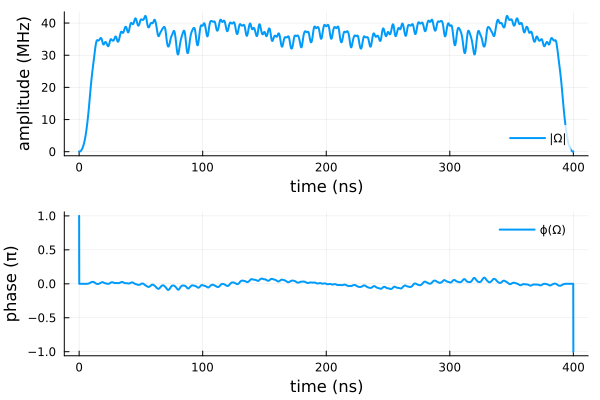

In [50]:
ϵ_opt_C = opt_result_C.optimized_controls[1] + 𝕚 * opt_result_C.optimized_controls[2]
Ω_opt_C = ϵ_opt_C .* discretize(Ωre_guess.shape, tlist)

fig = plot_complex_pulse(tlist, Ω_opt_C)

We then propagate the optimized control field to analyze the resulting
quantum gate:

In [51]:
opt_states_C = propagate_trajectories(
    substitute(
        trajectories,
        IdDict(zip(get_controls(trajectories), opt_result_C.optimized_controls))
    ),
    tlist;
    method=Cheby,
    use_threads=true
);

U_opt_C = [basis[i] ⋅ opt_states_C[j] for i = 1:4, j = 1:4];

We find that we have achieved a perfect entangler:

In [52]:
gate_concurrence(U_opt_C)

1.0

and negligible loss of population from the logical subspace

In [53]:
1 - unitarity(U_opt_C)

0.0006486436951114172

## Optimizing for perfect entangler in the Weyl chamber

The realization that the gate concurrence is a non-analytic functional for which one cannot write down a derivative prompts the question whether one can formulate an equivalent functional that *is* analytic. That approach was demonstrated in [Watts *et. al*, Phys. Rev. A 91, 062306 (2015)](https://michaelgoerz.net/#WattsPRA2015) and [Goerz *et al.*, Phys. Rev. A 91, 062307 (2015)](https://michaelgoerz.net/#GoerzPRA2015).

The basic idea is that the mathematical structure of the two-qubit gates in the Weyl chamber that we also used in the definition of the gate concurrence has a *geometric* interpretation. The set of perfect entanglers forms a compact polyhedron inside the Weyl chamber (the shaded region in the diagram), and we can optimize for a perfect entangler by minimizing the geometric distance to the surface of that polyhedron.

The distance measure to the surface of the polyhedron is implemented in the `TwoQubitWeylChamber` package:

In [54]:
using TwoQubitWeylChamber: D_PE

We convert it to a functional with `gate_functional`, adding a unitarity term, like before:

In [55]:
J_T_PE = gate_functional(D_PE; unitarity_weight=0.5);

The geometric distance to the polyhedron of perfect
entanglers in the Weyl chamber for the guess pulse is

In [56]:
D_PE(U_guess)

0.7787454222414767

Together with the unitarity measure, this is the initial value of the
optimization functional:

In [57]:
0.5 * D_PE(U_guess) + 0.5 * (1 - unitarity(U_guess))

0.4347310340894015

In [58]:
J_T_PE(guess_states, trajectories)

0.4347310340894015

The $J_{T,PE}$ functional has an analytic derivative – it is a high-order polynomial in the states. However, that derivative is still tedious to calculate and implement. There is a [Python implementation](https://github.com/qucontrol/weylchamber/blob/ec96621907c74da2ed1a746292f0e64237840bec/src/weylchamber/perfect_entanglers.py#L209), but that has not been translated to Julia. Thus, we will again use the automatic differentiation via Zygote to obtain the $\ket{\chi_k(T)}$ states:

In [59]:
chi_pe = make_gate_chi(D_PE, trajectories; unitarity_weight=0.5);

[ Info: make_gate_chi for J_T_U=D_PE: automatic with Zygote


We then use this in the optimization:

In [60]:
opt_result_PE = optimize(
    problem;
    method=GRAPE,
    J_T=J_T_PE,
    chi=chi_pe,
)

 iter.        J_T       ǁ∇Jǁ       ǁΔϵǁ         ΔJ   FG(F)    secs
     0   4.35e-01   3.92e-01        n/a        n/a    1(0)     2.6
     1   3.35e-01   3.92e-01   3.92e-01  -9.94e-02    1(0)     0.2
     2   1.69e-01   7.52e-01   7.79e-01  -1.67e-01    1(0)     0.2
     3   1.43e-01   3.19e-01   6.21e-01  -2.59e-02    1(0)     0.2
     4   1.00e-01   2.09e-01   2.69e-01  -4.24e-02    1(0)     0.1
     5   5.72e-02   2.24e-01   4.11e-01  -4.33e-02    2(0)     0.3
     6   4.96e-02   2.60e-01   4.30e-01  -7.51e-03    1(0)     0.1
     7   7.82e-03   5.41e-01   1.90e-01  -4.18e-02    1(0)     0.1
     8  -4.26e-03   1.82e-01   2.16e-01  -1.21e-02    1(0)     0.1


GRAPE Optimization Result
-------------------------
- Started at 2026-06-25T10:50:01.197
- Number of trajectories: 4
- Number of iterations: 8
- Number of pure func evals: 0
- Number of func/grad evals: 10
- Value of functional: -4.25769e-03
- Reason for termination: J_T < 10⁻³
- Ended at 2026-06-25T10:50:05.024 (3 seconds, 827 milliseconds)


Alternatively, using Krotov's method:

In [61]:
#=
opt_result_PE = optimize(
    problem;
    method=Krotov,
    J_T=J_T_PE,
    chi=chi_pe,
    lambda_a=1.0
)
=#

We extract the optimized control field from the optimization result and plot
it

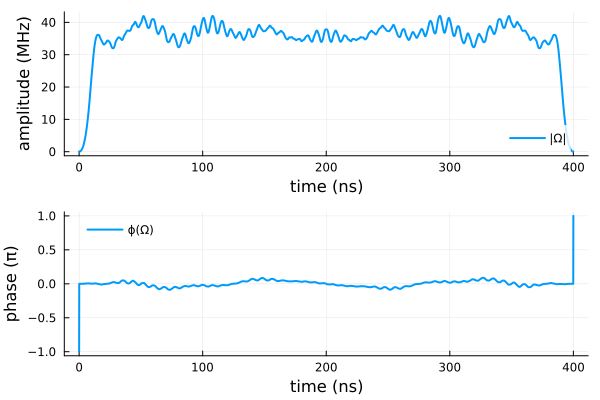

In [62]:
ϵ_opt_PE = opt_result_PE.optimized_controls[1] + 𝕚 * opt_result_PE.optimized_controls[2]
Ω_opt_PE = ϵ_opt_PE .* discretize(Ωre_guess.shape, tlist)

fig = plot_complex_pulse(tlist, Ω_opt_PE)

We then propagate the optimized control field to analyze the resulting
quantum gate:

In [63]:
opt_states_PE = propagate_trajectories(
    substitute(
        trajectories,
        IdDict(zip(get_controls(trajectories), opt_result_PE.optimized_controls))
    ),
    tlist;
    method=Cheby,
    use_threads=true
);

U_opt_PE = [basis[i] ⋅ opt_states_PE[j] for i = 1:4, j = 1:4];

We find that we have achieved a perfect entangler:

In [64]:
gate_concurrence(U_opt_PE)

1.0

Moreover, we have reduced the population loss to less than 4%

In [65]:
1 - unitarity(U_opt_PE)

0.03526169456326089

The relative weight of the `D_PE` and the unitarity term in the functional can be tuned to see whether this loss can be reduced further.